# 📊 Data Visualization in Python
### Using `matplotlib` and `seaborn`

Visualizations play a key role in data analysis. Before building any model or drawing conclusions, it's important to **visually explore your data** — to understand its shape, spot patterns, detect outliers, and check assumptions. This process is called **Exploratory Data Analysis (EDA)**, and plotting is at its core.

This notebook walks you through the most essential plot types in Python using two libraries:

- **`matplotlib`** — the foundational plotting library. Almost every other visualization tool in Python is built on top of it.
- **`seaborn`** — a higher-level library built on matplotlib. It produces cleaner statistical plots with less code and integrates natively with pandas DataFrames.

Each section explains **what the plot is**, **how to read it**, and **when to use it**, followed by a simple code example you can run and experiment with.

---
## ⚙️ Setup

Run this cell first. It imports all required libraries and creates a small sample dataset that we'll reuse across all examples.

> 💡 `%matplotlib inline` is a Jupyter magic command that makes plots appear directly inside the notebook instead of opening in a separate window.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

%matplotlib inline
sns.set_style('whitegrid')
# Basic x, y data for simple plots
x = [1, 2, 3, 4, 5]
y = [10, 25, 20, 35, 30]

print('Ready!')

Ready!


---
# Part 1 — matplotlib Plots

matplotlib's `pyplot` module provides a MATLAB-like interface for creating plots. The general pattern is:
1. Call a plot function (e.g. `plt.plot()`)
2. Add labels and a title
3. Call `plt.show()` to display it

---
## 1. Line Plot

### What is it?
A line plot connects data points in order with straight line segments. It is the simplest and most widely used plot in data analysis.

### How to read it
- The **x-axis** usually represents time or a sequential variable (e.g. months, steps).
- The **y-axis** represents the measured value.
- An **upward slope** means the value is increasing; a **downward slope** means it's decreasing.
- A **flat line** means no change over that period.

### When to use it
- Showing a trend over time (e.g. monthly sales, daily temperature)
- Comparing how multiple things change over the same time period
- Whenever your x-axis is continuous or sequential

### Syntax
```python
plt.plot(x, y)
```

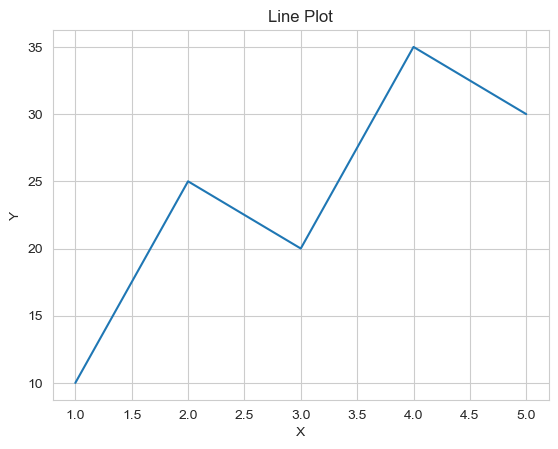

In [4]:
plt.plot(x, y)
plt.title('Line Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

---
## 2. Scatter Plot

### What is it?
A scatter plot displays individual data points on a 2D plane — one point per observation. Unlike a line plot, the points are **not connected**, so there's no implied sequence.

### How to read it
- Each dot = one data point (one row in your dataset).
- **Points going up from left to right** → positive correlation (as X increases, Y increases).
- **Points going down from left to right** → negative correlation.
- **No clear direction** → little or no linear relationship.
- **Points far from the main cluster** → potential outliers.

### When to use it
- Checking whether two numeric variables are related
- Identifying clusters or unusual data points
- Exploring data before fitting a regression model

### Syntax
```python
plt.scatter(x, y)
```

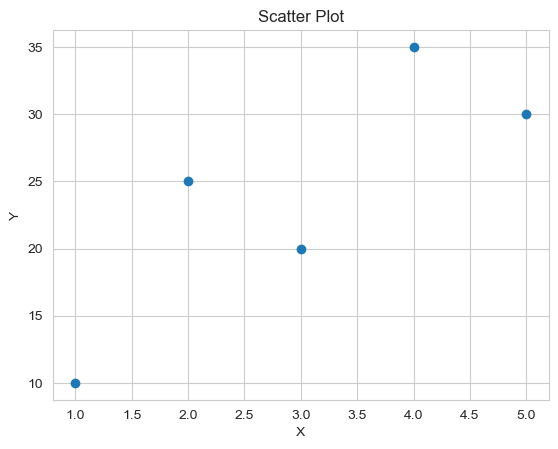

In [5]:
plt.scatter(x, y)
plt.title('Scatter Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

---
## 3. Histogram

### What is it?
A histogram groups a single numeric variable into **bins** (ranges of values) and shows how many data points fall into each bin. It reveals the **shape of the distribution**.

### How to read it
- The **x-axis** shows the range of values the variable can take.
- The **y-axis** shows how many data points fall into each range (frequency).
- A **tall bar** means many values fall in that range; a **short bar** means few.
- **Symmetric bell shape** → data is normally distributed.
- **Skewed to the right** → most values are low, with a few very high values.
- **Two peaks (bimodal)** → your data may contain two distinct groups.

### When to use it
- Understanding the spread and shape of a variable's distribution
- Checking if data is normally distributed (required by many statistical models)
- Detecting outliers at the far ends of the distribution

### Key parameter: `bins`
- Too **few** bins → you lose detail (everything looks the same)
- Too **many** bins → too noisy (hard to see the overall shape)
- A good starting point is `bins=20` or `bins=30`

### Syntax
```python
plt.hist(data, bins=20)
```

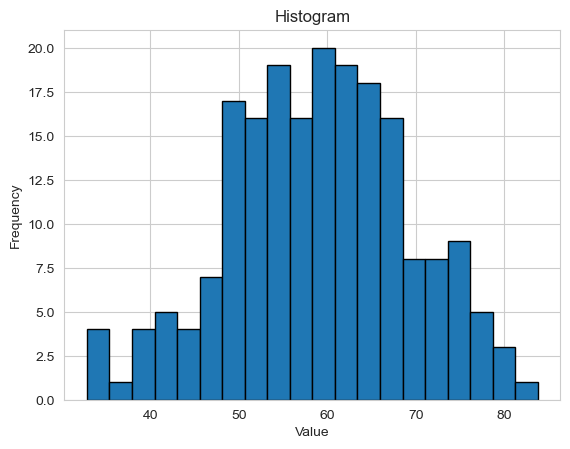

In [6]:
data = np.random.normal(60, 10, 200)  # 200 values centered around 60

plt.hist(data, bins=20, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

---
## 4. Bar Plot

### What is it?
A bar plot uses rectangular bars to compare values across **categories**. The height of each bar represents the value for that category.

### How to read it
- Each bar = one category (e.g. a product, a city, a month).
- **Taller bar** = higher value for that category.
- Easy to spot which category is the highest or lowest at a glance.

### Histogram vs Bar Plot — what's the difference?
| | Histogram | Bar Plot |
|---|---|---|
| Data type | Continuous numeric | Categorical |
| Bars touch? | Yes (continuous range) | No (separate categories) |
| Purpose | Show distribution | Compare categories |

### When to use it
- Comparing a metric (sales, count, score) across different groups or categories
- Ranking items from highest to lowest
- Showing survey results or frequency counts per category

### Syntax
```python
plt.bar(categories, values)
```
> 💡 For long category names, use `plt.barh()` (horizontal bars) for better readability.

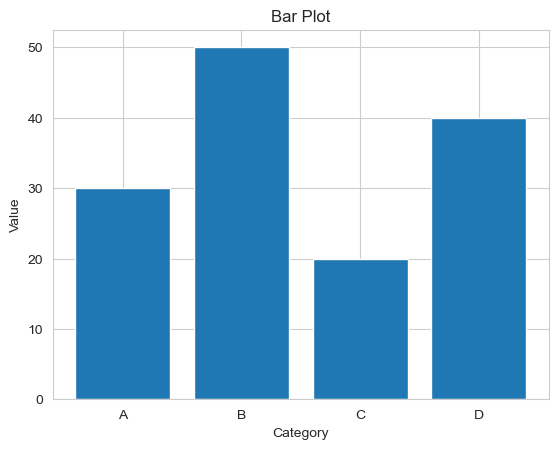

In [7]:
categories = ['A', 'B', 'C', 'D']
values     = [30, 50, 20, 40]

plt.bar(categories, values)
plt.title('Bar Plot')
plt.xlabel('Category')
plt.ylabel('Value')
plt.show()

---
## 5. Pseudo Color Plot

### What is it?
A pseudo color plot (pcolor) displays a **2D matrix as a grid of colored cells**. Each cell's color represents its numeric value — making it easy to spot high and low values across two dimensions simultaneously.

### How to read it
- The **rows** and **columns** represent two categorical variables (e.g. subjects and classes).
- The **color** of each cell encodes the numeric value (e.g. average score).
- A **color scale (colorbar)** on the side tells you which color maps to which value.
- **Darker/lighter regions** indicate where values are concentrated.

### When to use it
- Visualizing a pivot table grouped by two variables
- Displaying a correlation matrix
- Any time you have a matrix of values and want to spot patterns visually

### Syntax
```python
plt.pcolor(matrix, cmap='Blues')
plt.colorbar()
```
> 💡 Always call `plt.colorbar()` after `plt.pcolor()` so viewers know what the colors mean.

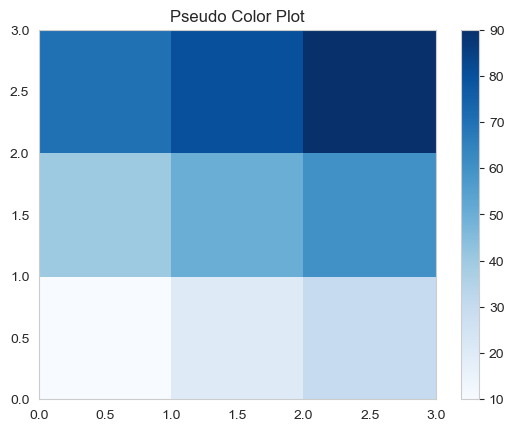

In [8]:
matrix = np.array([[10, 20, 30],
                    [40, 50, 60],
                    [70, 80, 90]])

plt.pcolor(matrix, cmap='Blues')
plt.colorbar()
plt.title('Pseudo Color Plot')
plt.show()

---
# Part 2 — seaborn Plots

seaborn is designed for **statistical visualization**. Key differences from matplotlib:

- Works directly with **pandas DataFrames** — you pass column names as strings instead of raw arrays.
- Produces **cleaner, more polished** charts with less code.
- Has built-in support for things like confidence intervals, regression lines, and distribution fitting.

We'll use a simple DataFrame for all seaborn examples below.

In [9]:
# Simple DataFrame for seaborn examples
df = pd.DataFrame({
    'hours': [1, 2, 3, 4, 5, 6, 7, 8],
    'score': [40, 45, 55, 58, 70, 72, 85, 90],
    'group': ['A', 'A', 'A', 'A', 'B', 'B', 'B', 'B']
})

print(df)

   hours  score group
0      1     40     A
1      2     45     A
2      3     55     A
3      4     58     A
4      5     70     B
5      6     72     B
6      7     85     B
7      8     90     B


---
## 6. Regression Plot

### What is it?
A regression plot draws a **scatter plot** of two variables and automatically fits and overlays a **linear regression line**. It also shades a **95% confidence interval** band around the line.

### How to read it
- The **dots** are the actual data points (same as a scatter plot).
- The **line** is the best-fit linear trend through the data.
- The **shaded band** around the line is the 95% confidence interval — a narrower band means the model is more confident about the line's position.
- A **steep slope** → strong linear relationship between the two variables.
- A **flat line** → little to no linear relationship.

### When to use it
- Quickly checking if a linear relationship exists between two variables
- Visualizing how well a straight line describes your data before building a regression model

### Syntax
```python
sns.regplot(x='column_name', y='column_name', data=df)
```

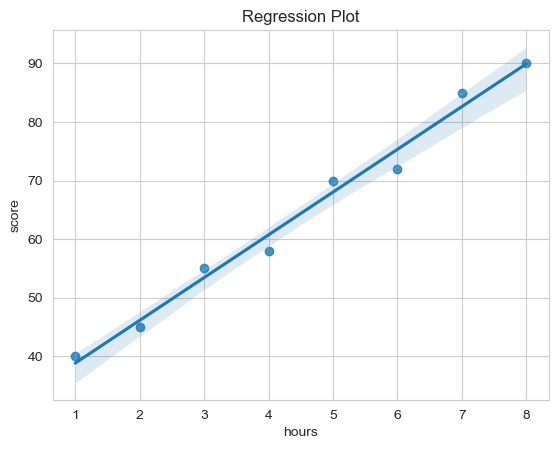

In [10]:
sns.regplot(x='hours', y='score', data=df)
plt.title('Regression Plot')
plt.show()

---
## 7. Box and Whisker Plot

### What is it?
A box plot summarizes the **distribution of a numeric variable** using five key statistics. It's especially useful for comparing distributions across multiple groups.

### How to read it
```
        |         ← top whisker (max, excluding outliers)
     ┌──┴──┐
     │     │  ← top of box = Q3 (75th percentile)
     │─────│  ← middle line = Median (50th percentile)
     │     │  ← bottom of box = Q1 (25th percentile)
     └──┬──┘
        |         ← bottom whisker (min, excluding outliers)
        o         ← outlier dot (beyond 1.5 × IQR)
```
- **IQR** (Interquartile Range) = Q3 − Q1. This is the height of the box.
- **Outliers** are points that fall more than 1.5 × IQR beyond the box edges.
- A **tall box** means high variability; a **short box** means data is tightly packed.
- If the **median line is off-center** inside the box, the data is skewed.

### When to use it
- Comparing distributions between two or more groups
- Quickly spotting outliers
- Getting a summary of spread, center, and skewness in one chart

### Syntax
```python
sns.boxplot(x='category_column', y='numeric_column', data=df)
```

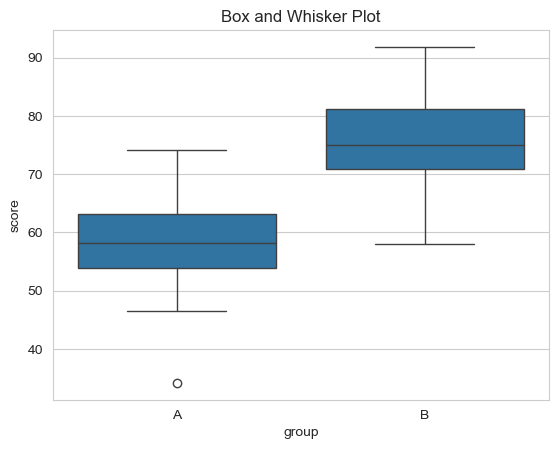

In [11]:
# A slightly larger dataset so the box plot is meaningful
df2 = pd.DataFrame({
    'group': ['A'] * 20 + ['B'] * 20,
    'score': list(np.random.normal(60, 10, 20)) + list(np.random.normal(75, 8, 20))
})

sns.boxplot(x='group', y='score', data=df2)
plt.title('Box and Whisker Plot')
plt.show()

---
## 8. Residual Plot

### What is it?
A residual plot shows the **errors of a regression model** — specifically, how far each prediction is from the actual value. A residual is simply:

> **Residual = Actual Value − Predicted Value**

seaborn fits a regression model internally and plots the residuals for you.

### How to read it
- The **x-axis** is the independent variable; the **y-axis** is the residual (error).
- The **red dashed line at 0** represents perfect predictions (zero error).
- ✅ **Good sign:** Points are randomly scattered above and below zero with no pattern.
- ⚠️ **Bad sign — curved pattern:** The true relationship is non-linear; a straight line isn't a good fit.
- ⚠️ **Bad sign — funnel shape:** The errors get bigger or smaller as X increases (called heteroscedasticity).
- ⚠️ **Large isolated points:** Influential outliers that are distorting the model.

### When to use it
- Checking the quality of a regression model after fitting it
- Diagnosing whether a linear model is appropriate for your data

### Syntax
```python
sns.residplot(x='column', y='column', data=df)
```

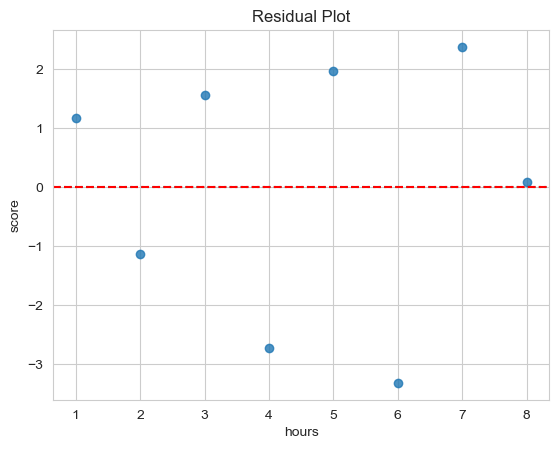

In [12]:
sns.residplot(x='hours', y='score', data=df)
plt.axhline(0, color='red', linestyle='--')  # reference line at zero error
plt.title('Residual Plot')
plt.show()

---
## 9. KDE Plot (Kernel Density Estimate)

### What is it?
A KDE plot draws a **smooth continuous curve** that estimates the probability distribution of a variable. You can think of it as a **smoothed-out histogram** — instead of rigid bars, you get a flowing curve.

### How to read it
- The **x-axis** shows the range of values.
- The **y-axis** shows the estimated probability density.
- **Peaks** in the curve show where values are most concentrated.
- **Tails** show how spread out the data is.
- The **total area under the curve always equals 1** (it's a probability distribution).
- You can overlay **multiple KDE curves** on the same plot to compare two distributions (e.g. actual vs. predicted values).

### KDE vs Histogram — what's the difference?
| | Histogram | KDE Plot |
|---|---|---|
| Shape | Stepped bars | Smooth curve |
| Affected by bin size? | Yes | No |
| Shows probability? | Approximately | Yes (area = 1) |

### When to use it
- When you want a cleaner alternative to a histogram
- Comparing the distributions of two variables on the same chart
- Checking if model predictions follow the same distribution as actual values

### Syntax
```python
sns.kdeplot(data, fill=True)
```

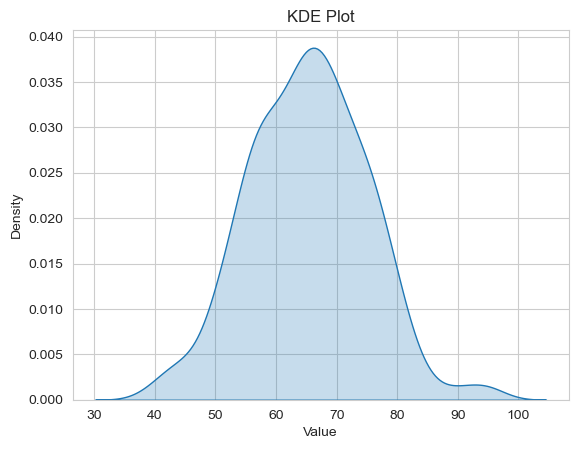

In [13]:
data = np.random.normal(65, 10, 300)

sns.kdeplot(data, fill=True)
plt.title('KDE Plot')
plt.xlabel('Value')
plt.show()

---
## 10. Distribution Plot

### What is it?
A distribution plot combines a **histogram** and a **KDE curve** into a single chart. It gives you the best of both worlds — the raw frequency counts from the histogram, and the smooth shape from the KDE curve.

### How to read it
- The **bars** (histogram) show the actual count of values in each bin.
- The **curve** (KDE) shows the estimated smooth distribution shape.
- Together, they make it easy to see both the **raw data** and the **underlying pattern**.

### Relationship to KDE Plot
The distribution plot is essentially a KDE plot with the histogram bars kept visible. In many EDA workflows, you can use either interchangeably — the distribution plot just gives extra context.

> ⚠️ **Note:** The old `sns.distplot()` function is **deprecated** in newer versions of seaborn. Always use `sns.histplot(kde=True)` instead.

### When to use it
- When you want to see both the raw distribution (bars) and the smooth shape (curve) at the same time
- Great for a first look at any numeric variable in your dataset

### Syntax
```python
sns.histplot(data, kde=True)   # modern syntax
```

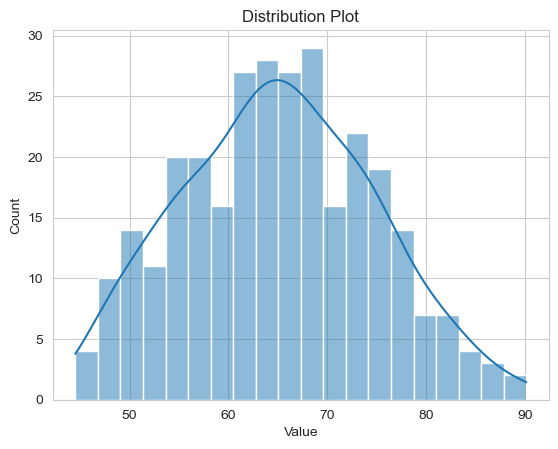

In [14]:
data = np.random.normal(65, 10, 300)

sns.histplot(data, kde=True, bins=20)
plt.title('Distribution Plot')
plt.xlabel('Value')
plt.show()

---
## 📋 Quick Reference

| # | Plot | Library | Syntax | Use it when... |
|---|---|---|---|---|
| 1 | Line Plot | matplotlib | `plt.plot(x, y)` | Showing a trend over time |
| 2 | Scatter Plot | matplotlib | `plt.scatter(x, y)` | Checking if two variables are related |
| 3 | Histogram | matplotlib | `plt.hist(x, bins)` | Seeing how a variable is distributed |
| 4 | Bar Plot | matplotlib | `plt.bar(x, height)` | Comparing values across categories |
| 5 | Pseudo Color | matplotlib | `plt.pcolor(matrix)` | Visualizing a matrix or pivot table |
| 6 | Regression Plot | seaborn | `sns.regplot(x, y, data)` | Visualizing a linear trend + confidence band |
| 7 | Box Plot | seaborn | `sns.boxplot(x, y, data)` | Comparing group distributions and outliers |
| 8 | Residual Plot | seaborn | `sns.residplot(x, y, data)` | Checking regression model quality |
| 9 | KDE Plot | seaborn | `sns.kdeplot(data)` | Smooth view of a variable's distribution |
| 10 | Distribution Plot | seaborn | `sns.histplot(data, kde=True)` | Histogram + KDE curve combined |